In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [2]:
from torchvision.models import(
    alexnet,AlexNet_Weights,vgg16,VGG16_Weights,
    densenet121,DenseNet121_Weights
)

In [2]:
from torch.utils.data import DataLoader,Subset
import time
import pandas as pd


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print("orginal dataset")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2940s 17us/step
orginal dataset
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


**convert data type and normalize**

In [9]:
X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

print("after preprocessing")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

after preprocessing
X_train shape: (50000, 32, 32, 3)
X_test shape: (10000, 32, 32, 3)


**CREATE VALIDATION DATA**

In [10]:
from re import X
X_val = X_train[-5000:]
y_val = y_train[-5000:]
X_train = X_train[:-5000]
y_train = y_train[:-5000]
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (45000, 32, 32, 3)
X_val shape: (5000, 32, 32, 3)


**10class names**

In [12]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
     ]

**display images**

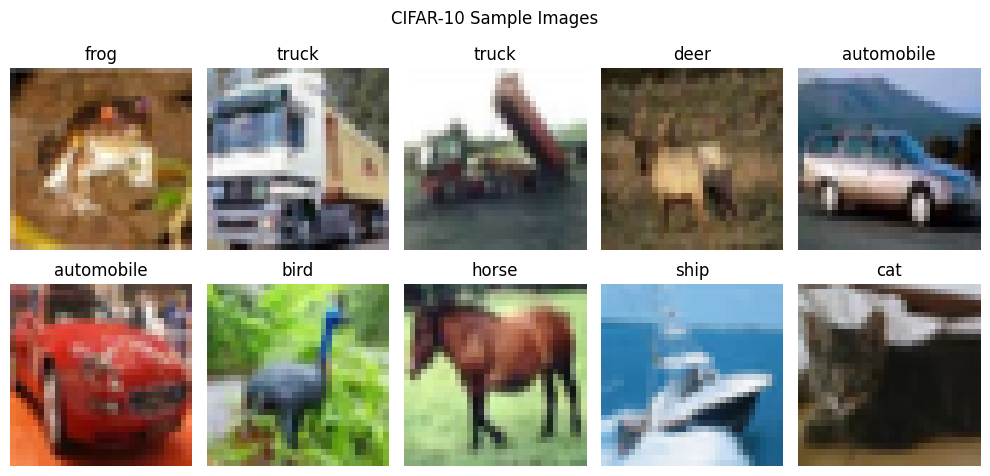

In [16]:
plt.figure(figsize=(10, 5))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i]])
  plt.axis("off")
plt.suptitle("CIFAR-10 Sample Images")
plt.tight_layout()
plt.show()

In [23]:
data_augmentation = tf.keras.Sequential([
     layers.RandomFlip("horizontal"),

     layers.RandomRotation(0.1),
     layers.RandomZoom(0.1) ])

**alexnet**

In [25]:
def build_alexnet():
    model = models.Sequential(name="AlexNet")
    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(data_augmentation)
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Conv2D(192, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Conv2D(384, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(256, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(256, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation="softmax"))
    return model


**vggnet16**

In [26]:
def build_vggnet():
    model = models.Sequential(name="VGGNet")
    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(data_augmentation)
    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(256, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(256, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation="softmax"))
    return model


**densenet**

In [27]:
def build_densenet():
    base_model = tf.keras.applications.DenseNet121(
        include_top=False,
        weights=None,
        input_shape=(32, 32, 3),
        pooling="avg",
    )
    model = models.Sequential(name="DenseNet")
    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(data_augmentation)
    model.add(base_model)
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(10, activation="softmax"))
    return model


**compile**

In [28]:
def compile_model(model):
  model.compile(
      optimizer=tf.keras.optimizers.Adam(
      learning_rate=0.001 ),
                 loss="sparse_categorical_crossentropy",
                                        metrics=["accuracy"] )
  return model

In [29]:
print("\nCreating models...")
alexnet = build_alexnet()
vggnet = build_vggnet()
densenet = build_densenet()


Creating models...


In [30]:

alexnet = compile_model(alexnet)
vggnet = compile_model(vggnet)
densenet = compile_model(densenet)

In [31]:
print("\n")
print("=" * 70)
print("ALEXNET ARCHITECTURE")
print("=" * 70)
alexnet.summary()
print("\n")
print("=" * 70)
print("VGGNET ARCHITECTURE")
print("=" * 70)
vggnet.summary()
print("\n")
print("=" * 70)
print("DENSENET ARCHITECTURE")
print("=" * 70)
densenet.summary()



ALEXNET ARCHITECTURE


Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 192)    │       110,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       663,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,483,146 (17.10 MB)

 Trainable params: 4,483,146 (17.10 MB)

...

Model: "DenseNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,047,754 (26.89 MB)

 Trainable params: 6,964,106 (26.57 MB)

 Non-trainable params: 83,648 (326.75 KB)

# **earlystopping**

In [32]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
    )

**training function**

In [35]:
def train_model(model, model_name, epochs=10):
  print("\n")
  print("=" * 70)
  print("TRAINING:", model_name)
  print("=" * 70)
  start_time = time.time()
  history = model.fit(
      X_train, y_train,
      validation_data=(
          X_val,
          y_val
          ),
      epochs=epochs,
      batch_size=128,
      callbacks=[ early_stopping
                 ],
      verbose=1
      )
  end_time = time.time()
  training_time = end_time - start_time
  print("\nTraining completed.")
  print("Training time:", round(training_time, 2), "seconds")
  return history, training_time

**alexnet training**

In [36]:
alex_history, alex_time = train_model(
    alexnet,
    "AlexNet",
    epochs=3
    )



TRAINING: AlexNet
Epoch 1/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.2738 - loss: 1.9333 - val_accuracy: 0.4188 - val_loss: 1.5569
Epoch 2/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4322 - loss: 1.5565 - val_accuracy: 0.5002 - val_loss: 1.3883
Epoch 3/3
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.5039 - loss: 1.3816 - val_accuracy: 0.5880 - val_loss: 1.1464

Training completed.
Training time: 40.29 seconds


**TRAINING OF VGGNET**

In [36]:
vgg_history, vgg_time = train_model(
    vggnet,
    "VGGNet",
    epochs=4
    )

In [58]:
vgg_history, vgg_time = train_model(
    vggnet,
    "VGGNet",
    epochs=4
    )



TRAINING: VGGNet
Epoch 1/4
352/352 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - accuracy: 0.3664 - loss: 1.7339 - val_accuracy: 0.5076 - val_loss: 1.3473
Epoch 2/4
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.5122 - loss: 1.3591 - val_accuracy: 0.5936 - val_loss: 1.1431
Epoch 3/4
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.5897 - loss: 1.1602 - val_accuracy: 0.6716 - val_loss: 0.9317
Epoch 4/4
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.6318 - loss: 1.0492 - val_accuracy: 0.6720 - val_loss: 0.9567

Training completed.
Training time: 90.33 seconds


In [59]:
results = pd.DataFrame(
    { "Model": [
    "AlexNet",
    "VGGNet",
    "DenseNet"
    ],
    "Test Accuracy (%)": [
    alex_acc * 100,
    vgg_acc * 100,
    dense_acc * 100 ],
    "Test Loss": [
    alex_loss,
    vgg_loss,
    dense_loss ],
    "Training Time (sec)": [
    alex_time,
    vgg_time,
    dense_time ],
    "Parameters": [
    alex_params,
    vgg_params,
    dense_params ] })
# Round numerical values
results["Test Accuracy (%)"] = results["Test Accuracy (%)"].round(2)
results["Test Loss"] = results["Test Loss"].round(4)
results["Training Time (sec)"] = results["Training Time (sec)"].round(2)
print("\n")
print("=" * 70)
print("FINAL PERFORMANCE COMPARISON")
print("=" * 70)
print(results.to_string(index=False))



FINAL PERFORMANCE COMPARISON
   Model  Test Accuracy (%)  Test Loss  Training Time (sec)  Parameters
 AlexNet              57.75     1.1804                40.29     4483146
  VGGNet               9.93     2.3051                90.33     9502730
DenseNet              19.59     2.6716               291.65     7047754


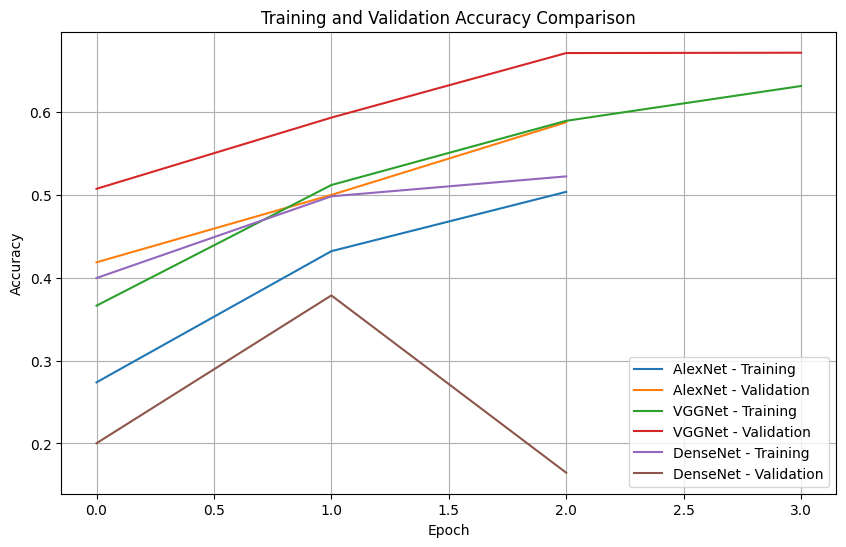

In [60]:
plt.figure(figsize=(10, 6))
plt.plot( alex_history.history["accuracy"],
         label="AlexNet - Training" )
plt.plot( alex_history.history["val_accuracy"],
         label="AlexNet - Validation" )
plt.plot( vgg_history.history["accuracy"],
         label="VGGNet - Training" )
plt.plot( vgg_history.history["val_accuracy"],
         label="VGGNet - Validation" )
plt.plot( dense_history.history["accuracy"],
         label="DenseNet - Training" )
plt.plot( dense_history.history["val_accuracy"],
         label="DenseNet - Validation" )
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title( "Training and Validation Accuracy Comparison" )
plt.legend()
plt.grid()
plt.show()

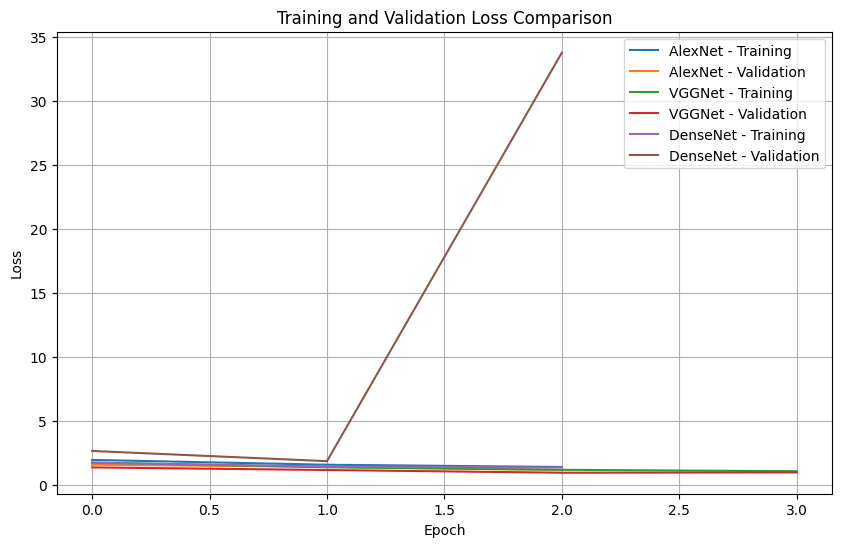

In [61]:
plt.figure(figsize=(10, 6))
plt.plot( alex_history.history["loss"],
         label="AlexNet - Training" )
plt.plot( alex_history.history["val_loss"],
         label="AlexNet - Validation" )
plt.plot( vgg_history.history["loss"],
         label="VGGNet - Training" )
plt.plot( vgg_history.history["val_loss"],
         label="VGGNet - Validation" )
plt.plot( dense_history.history["loss"],
         label="DenseNet - Training" )
plt.plot( dense_history.history["val_loss"],
         label="DenseNet - Validation" )
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title( "Training and Validation Loss Comparison" )
plt.legend()
plt.grid()
plt.show()

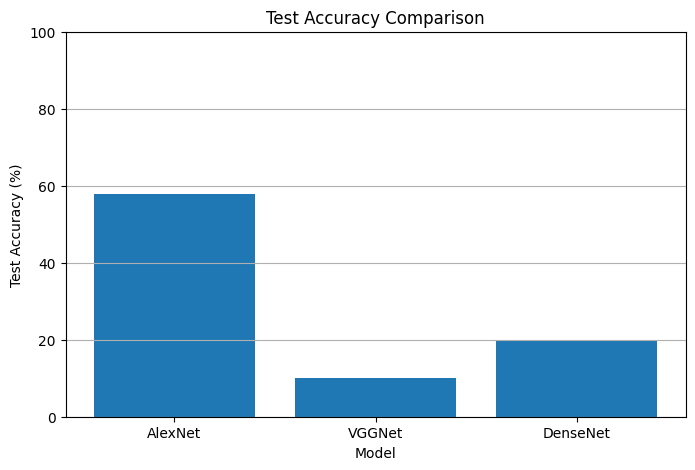

In [62]:
plt.figure(figsize=(8, 5))
plt.bar( results["Model"], results["Test Accuracy (%)"] )
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title( "Test Accuracy Comparison" )
plt.ylim(0, 100)
plt.grid( axis="y" )
plt.show()

**TRAINING OF DENSENET**

In [37]:
dense_history, dense_time = train_model(
    densenet, "DenseNet",
    epochs=10 )



TRAINING: DenseNet
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 153s 223ms/step - accuracy: 0.3998 - loss: 1.7012 - val_accuracy: 0.2002 - val_loss: 2.6341
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 69s 196ms/step - accuracy: 0.4985 - loss: 1.4192 - val_accuracy: 0.3788 - val_loss: 1.8362
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 68s 194ms/step - accuracy: 0.5226 - loss: 1.3426 - val_accuracy: 0.1646 - val_loss: 33.7659

Training completed.
Training time: 291.65 seconds


**EVALUATE THE MODEL**

In [52]:
def evaluate_model(model, model_name):
  print("\n")
  print("=" * 70)
  print("EVALUATION:", model_name)
  print("=" * 70)
  test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
    )
  print("Test Loss :", round(test_loss, 4))
  print("Test Accuracy :", round(test_accuracy * 100, 2), "%")
  return test_loss, test_accuracy

In [55]:
alex_loss, alex_acc = evaluate_model(
    alexnet,
    "AlexNet"
    )
vgg_loss, vgg_acc = evaluate_model(
    vggnet,
                                   "VGGNet" )
dense_loss, dense_acc = evaluate_model(
    densenet,
    "DenseNet"
    )



EVALUATION: AlexNet
Test Loss : 1.1804
Test Accuracy : 57.75 %


EVALUATION: VGGNet
Test Loss : 2.3051
Test Accuracy : 9.93 %


EVALUATION: DenseNet
Test Loss : 2.6716
Test Accuracy : 19.59 %


**COUNTING PARAMETERS**

In [56]:
alex_params = alexnet.count_params()
vgg_params = vggnet.count_params()
dense_params = densenet.count_params()

**CREATING PERFORMANCE TABLESS**

In [63]:
results = pd.DataFrame(
    { "Model": [
    "AlexNet",
    "VGGNet",
    "DenseNet"
    ],
    "Test Accuracy (%)": [
    alex_acc * 100,
    vgg_acc * 100,
    dense_acc * 100 ],
    "Test Loss": [
    alex_loss,
    vgg_loss,
    dense_loss ],
    "Training Time (sec)": [
    alex_time,
    vgg_time,
    dense_time ],
    "Parameters": [
    alex_params,
    vgg_params,
    dense_params ] })
# Round numerical values
results["Test Accuracy (%)"] = results["Test Accuracy (%)"].round(2)
results["Test Loss"] = results["Test Loss"].round(4)
results["Training Time (sec)"] = results["Training Time (sec)"].round(2)
print("\n")
print("=" * 70)
print("FINAL PERFORMANCE COMPARISON")
print("=" * 70)
print(results.to_string(index=False))



FINAL PERFORMANCE COMPARISON
   Model  Test Accuracy (%)  Test Loss  Training Time (sec)  Parameters
 AlexNet              57.75     1.1804                40.29     4483146
  VGGNet               9.93     2.3051                90.33     9502730
DenseNet              19.59     2.6716               291.65     7047754


**PLOTTING TRAINING ACCURACY**

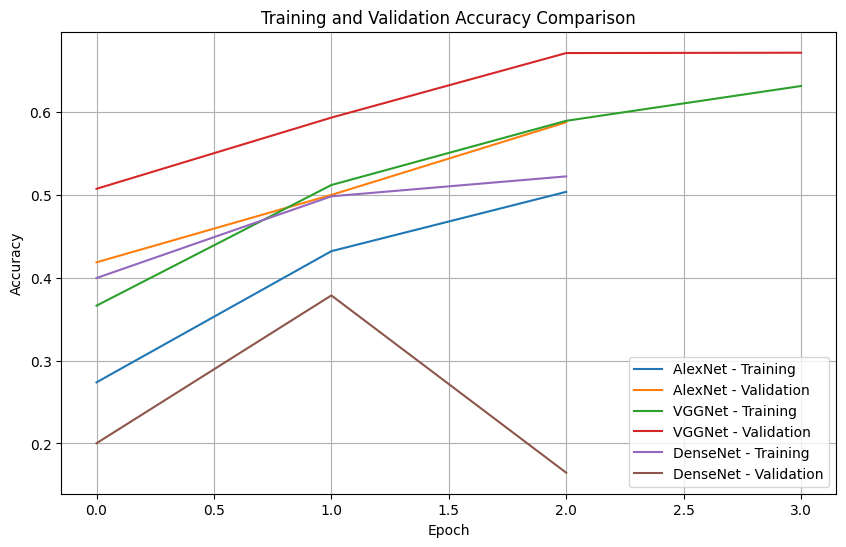

In [65]:
plt.figure(figsize=(10, 6))
plt.plot( alex_history.history["accuracy"],
         label="AlexNet - Training" )
plt.plot( alex_history.history["val_accuracy"],
         label="AlexNet - Validation" )
plt.plot( vgg_history.history["accuracy"],
         label="VGGNet - Training" )
plt.plot( vgg_history.history["val_accuracy"],
         label="VGGNet - Validation" )
plt.plot( dense_history.history["accuracy"],
         label="DenseNet - Training" )
plt.plot( dense_history.history["val_accuracy"],
         label="DenseNet - Validation" )
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title( "Training and Validation Accuracy Comparison" )
plt.legend()
plt.grid()
plt.show()

**PLOTTING TRAINING LOSS**

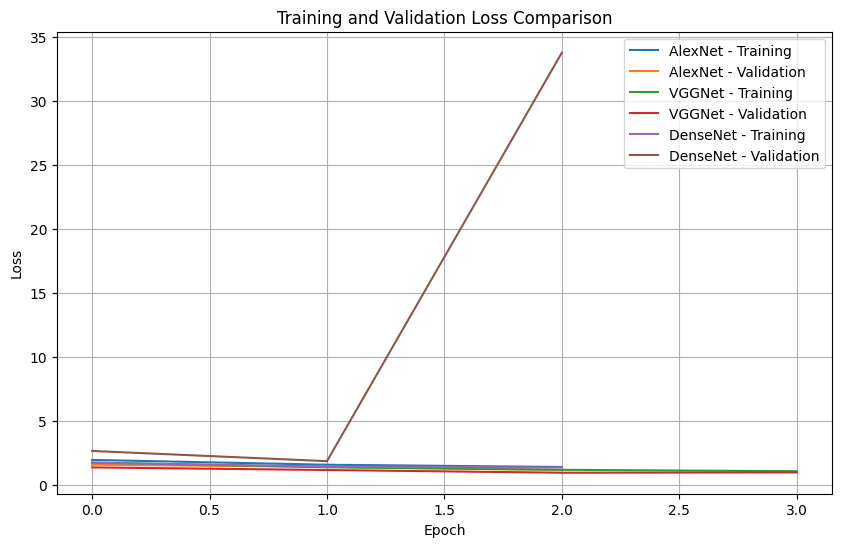

In [67]:
plt.figure(figsize=(10, 6))
plt.plot( alex_history.history["loss"],
         label="AlexNet - Training" )
plt.plot( alex_history.history["val_loss"],
         label="AlexNet - Validation" )
plt.plot( vgg_history.history["loss"],
         label="VGGNet - Training" )
plt.plot( vgg_history.history["val_loss"],
         label="VGGNet - Validation" )
plt.plot( dense_history.history["loss"],
         label="DenseNet - Training" )
plt.plot( dense_history.history["val_loss"],
         label="DenseNet - Validation" )
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title( "Training and Validation Loss Comparison" )
plt.legend()
plt.grid()
plt.show()

**BAR GRAPH - accuracy**

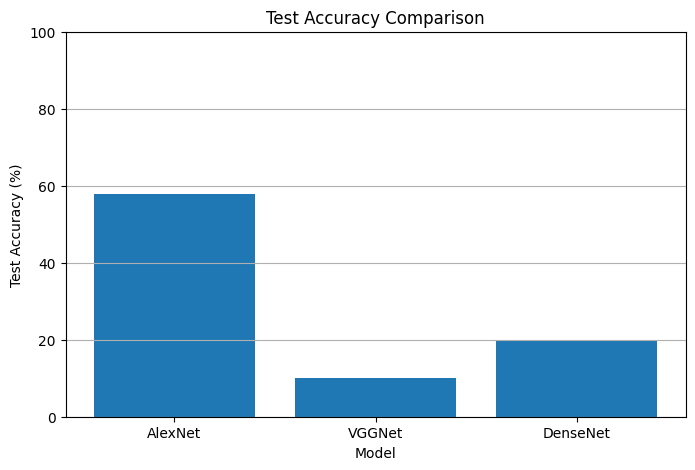

In [68]:
plt.figure(figsize=(8, 5))
plt.bar( results["Model"], results["Test Accuracy (%)"] )
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title( "Test Accuracy Comparison" )
plt.ylim(0, 100)
plt.grid( axis="y" )
plt.show()

**bar graph - training time**

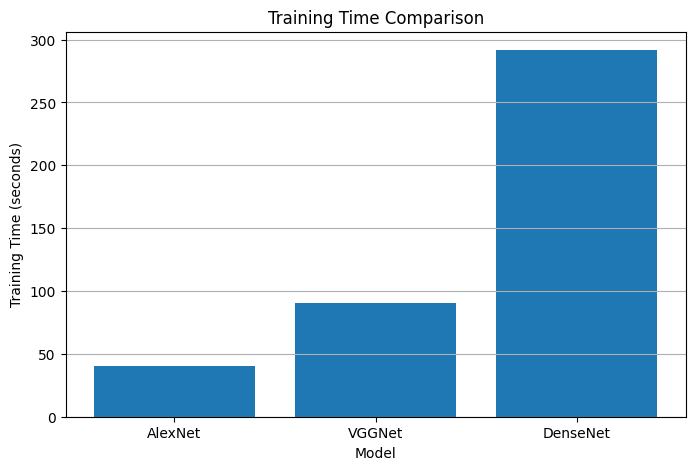

In [69]:
plt.figure(figsize=(8, 5))
plt.bar( results["Model"], results["Training Time (sec)"] )
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title( "Training Time Comparison" )
plt.grid( axis="y" )
plt.show()

**bar graph no of params**

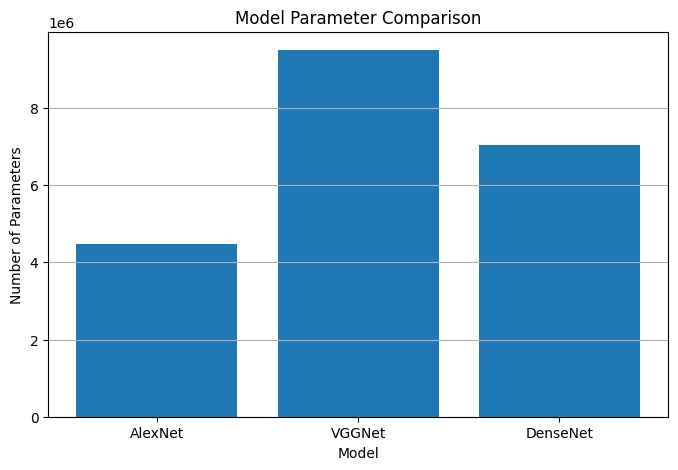

In [70]:
plt.figure(figsize=(8, 5))
plt.bar( results["Model"], results["Parameters"] )
plt.xlabel("Model")
plt.ylabel("Number of Parameters")
plt.title( "Model Parameter Comparison" )
plt.grid( axis="y" )
plt.show()

**function for predioction**

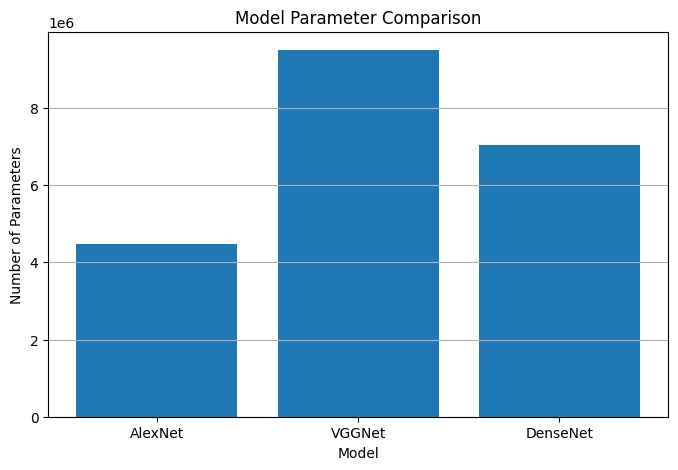

In [71]:
plt.figure(figsize=(8, 5))
plt.bar( results["Model"], results["Parameters"] )
plt.xlabel("Model")
plt.ylabel("Number of Parameters")
plt.title( "Model Parameter Comparison" )
plt.grid( axis="y" )
plt.show()

**test predictions**

In [74]:
def predict_image(model, image, true_label):
  image = np.expand_dims(image, axis=0)
  predictions = model.predict(image, verbose=0)
  predicted_class = np.argmax(predictions[0])
  confidence = np.max(predictions[0]) * 100
  actual_class_name = class_names[true_label]
  predicted_class_name = class_names[predicted_class]
  return actual_class_name, predicted_class_name, confidence

print("\n")
print("=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)
for index in range(10):
  actual_a, pred_a, conf_a = predict_image(
      alexnet,
      X_test[index],
      y_test[index]
      )
  actual_v, pred_v, conf_v = predict_image(
      vggnet,
      X_test[index],
      y_test[index]
      )
  actual_d, pred_d, conf_d = predict_image(
      densenet,
      X_test[index],
      y_test[index]
      )
  print("\nImage", index + 1)
  print( "Actual Class :", actual_a )
  print( "AlexNet :", pred_a, "(", round(conf_a, 2), "%)" )
  print( "VGGNet :", pred_v, "(", round(conf_v, 2), "%)" )
  print( "DenseNet :", pred_d, "(", round(conf_d, 2), "%)" )



SAMPLE PREDICTIONS

Image 1
Actual Class : cat
AlexNet : cat ( 54.47 %)
VGGNet : cat ( 47.51 %)
DenseNet : ship ( 31.13 %)

Image 2
Actual Class : ship
AlexNet : automobile ( 86.33 %)
VGGNet : ship ( 97.48 %)
DenseNet : automobile ( 39.78 %)

Image 3
Actual Class : ship
AlexNet : ship ( 62.42 %)
VGGNet : ship ( 44.72 %)
DenseNet : ship ( 98.93 %)

Image 4
Actual Class : airplane
AlexNet : airplane ( 32.9 %)
VGGNet : airplane ( 48.22 %)
DenseNet : airplane ( 37.33 %)

Image 5
Actual Class : frog
AlexNet : frog ( 54.15 %)
VGGNet : frog ( 91.63 %)
DenseNet : dog ( 18.21 %)

Image 6
Actual Class : frog
AlexNet : frog ( 77.67 %)
VGGNet : frog ( 97.24 %)
DenseNet : dog ( 39.45 %)

Image 7
Actual Class : automobile
AlexNet : automobile ( 81.24 %)
VGGNet : automobile ( 94.33 %)
DenseNet : dog ( 29.71 %)

Image 8
Actual Class : frog
AlexNet : frog ( 82.96 %)
VGGNet : frog ( 80.06 %)
DenseNet : bird ( 30.83 %)

Image 9
Actual Class : cat
AlexNet : cat ( 41.52 %)
VGGNet : cat ( 58.52 %)
DenseNe

**visualization of the predictions**

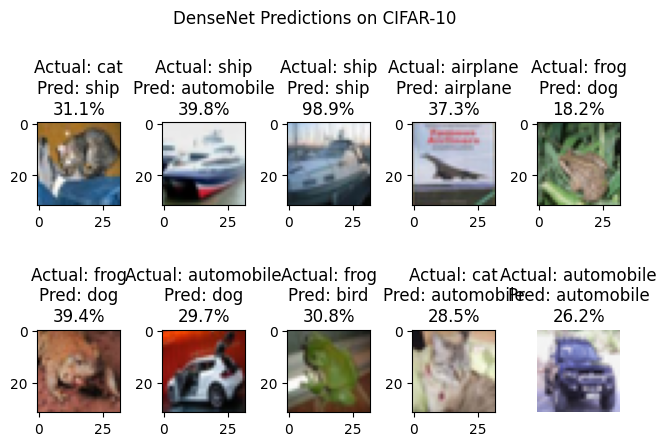

In [77]:
for i in range(10):
  prediction = densenet.predict(
      np.expand_dims(
          X_test[i],
          axis=0 ),
      verbose=0
      )
  predicted_class = np.argmax(
      prediction[0]
      )
  confidence = np.max(
      prediction[0]
      ) * 100
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_test[i])
  plt.title( "Actual: " +
            class_names[y_test[i]] +
             "\nPred: " +
             class_names[predicted_class] +
             f"\n{confidence:.1f}%"
              )
plt.axis("off")
plt.suptitle( "DenseNet Predictions on CIFAR-10" )
plt.tight_layout()
plt.show()

In [78]:
results.to_csv( "CNN_Model_Performance_Comparison.csv",
               index=False
               )
print("\nPerformance table saved as:")
print("CNN_Model_Performance_Comparison.csv")


Performance table saved as:
CNN_Model_Performance_Comparison.csv


In [79]:
alexnet.save( "AlexNet_CIFAR10.keras" )
vggnet.save( "VGGNet_CIFAR10.keras" )
densenet.save( "DenseNet_CIFAR10.keras" )
print("\nModels saved successfully.")


Models saved successfully.


In [80]:
print("=" * 70)
print("EXPERIMENT COMPLETED")
print("=" * 70)
print(""" AlexNet, VGGNet and DenseNet were implemented using the CIFAR-10 dataset.
The models were compared using:
 1. Test Accuracy
  2. Test Loss
  3. Training Time
  4. Number of Parameters
  The experimental results can be analyzed using the
  generated performance table and graphs. """)

EXPERIMENT COMPLETED
 AlexNet, VGGNet and DenseNet were implemented using the CIFAR-10 dataset.
The models were compared using:
 1. Test Accuracy
  2. Test Loss
  3. Training Time
  4. Number of Parameters
  The experimental results can be analyzed using the
  generated performance table and graphs. 
